In [1]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Setup complete. Torch:", torch.__version__)


Setup complete. Torch: 2.8.0+cpu


In [5]:
df_train = pd.read_csv("fashion-mnist_train.csv")
df_test  = pd.read_csv("fashion-mnist_test.csv")
print("Loaded shape:", df_train.shape)
print("Loaded shape test:", df_test.shape)

# Heuristics: handle label column if present
label_col = None
for cand in ["label", "target", "y", "class"]:
    if cand in df_train.columns:
        label_col = cand
        break

if label_col is not None:
    y_train_all = df_train[label_col].values.astype(np.int64)
    X_train_all = df_train.drop(columns=[label_col]).values.astype(np.float32)

    y_test = df_test[label_col].values.astype(np.int64)
    X_test = df_test.drop(columns=[label_col]).values.astype(np.float32)
else:
    y_train_all = y_test = None
    X_train_all = df_train.values.astype(np.float32)
    X_test = df_test.values.astype(np.float32)

# Normalize to [0,1]
if X_train_all.max() > 1.0:
    X_train_all /= 255.0
    X_test /= 255.0

# Create validation split from training data
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all,
    test_size=0.1, random_state=SEED,
    stratify=y_train_all if y_train_all is not None else None
)

def make_tensor_dataset(X_arr, y_arr):
    X_t = torch.tensor(X_arr, dtype=torch.float32)
    if X_t.ndim == 2:  # if flattened (784)
        X_t = X_t.view(-1, 1, 28, 28)
    if y_arr is None:
        return TensorDataset(X_t)
    else:
        y_t = torch.tensor(y_arr, dtype=torch.long)
        return TensorDataset(X_t, y_t)

train_ds = make_tensor_dataset(X_train, y_train)
val_ds   = make_tensor_dataset(X_val, y_val)
test_ds  = make_tensor_dataset(X_test, y_test)

print("✅ Train/Val/Test datasets ready and normalized to [0,1]")


Loaded shape: (60000, 785)
Loaded shape test: (10000, 785)
✅ Train/Val/Test datasets ready and normalized to [0,1]


In [3]:
class Flatten(nn.Module):
    def forward(self, x):
        return x.view(x.size(0), -1)

class Unflatten(nn.Module):
    def __init__(self, channels=1, height=28, width=28):
        super().__init__()
        self.c, self.h, self.w = channels, height, width
    def forward(self, x):
        return x.view(x.size(0), self.c, self.h, self.w)

class VAE(nn.Module):
    def __init__(self, latent_dim=20):
        super().__init__()
        self.latent_dim = latent_dim
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.ReLU(inplace=True),
            Flatten(),
        )
        
        with torch.no_grad():
            dummy = torch.zeros(1,1,28,28)
            enc_out = self.encoder(dummy)
            self.enc_flat_dim = enc_out.shape[1]
        
        self.fc_mu    = nn.Linear(self.enc_flat_dim, latent_dim)
        self.fc_logvar= nn.Linear(self.enc_flat_dim, latent_dim)
        
        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 128*4*4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(16, 1, kernel_size=3, padding=2),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def decode(self, z):
        h = self.decoder_input(z)
        h = h.view(-1, 128, 4, 4)
        x_hat = self.decoder(h)
        if x_hat.shape[-1] != 28:
            c = (x_hat.shape[-1] - 28) // 2
            x_hat = x_hat[:, :, c:c+28, c:c+28]
        return x_hat
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.decode(z)
        return x_hat, mu, logvar, z

print("VAE class defined (with encoder, decoder, and reparameterization).")


VAE class defined (with encoder, decoder, and reparameterization).


In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vae = VAE(latent_dim=20).to(device)
print("Model parameters:", sum(p.numel() for p in vae.parameters()))

if 'train_ds' in globals() and train_ds is not None:
    loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    batch = next(iter(loader))
    X_batch = batch[0] if isinstance(batch, (list, tuple)) else batch
    X_batch = X_batch.to(device)
    with torch.no_grad():
        x_hat, mu, logvar, z = vae(X_batch)
    print("Input shape:", X_batch.shape, "| Recon shape:", x_hat.shape)
    print("Latent mu/logvar/z shapes:", mu.shape, logvar.shape, z.shape)
else:
    X_fake = torch.rand(8, 1, 28, 28, device=device)
    with torch.no_grad():
        x_hat, mu, logvar, z = vae(X_fake)
    print("Synthetic test — Input:", X_fake.shape, "Recon:", x_hat.shape)
    print("Latent mu/logvar/z:", mu.shape, logvar.shape, z.shape)


Model parameters: 389929
Input shape: torch.Size([64, 1, 28, 28]) | Recon shape: torch.Size([64, 1, 28, 28])
Latent mu/logvar/z shapes: torch.Size([64, 20]) torch.Size([64, 20]) torch.Size([64, 20])


In [6]:
import math
import matplotlib.pyplot as plt

# ----- ELBO components -----
def recon_loss_BCE(x_hat, x):
    # BCE over pixels, summed then normalized per batch
    b = x.size(0)
    return torch.nn.functional.binary_cross_entropy(
        x_hat, x, reduction="sum"
    ) / b

def kl_divergence(mu, logvar):
    # KL(N(mu, sigma) || N(0, I)) = -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    b = mu.size(0)
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return kld / b

def elbo_loss(x_hat, x, mu, logvar, beta=1.0):
    rec = recon_loss_BCE(x_hat, x)
    kld = kl_divergence(mu, logvar)
    loss = rec + beta * kld
    return loss, rec, kld

# ----- Visualization helper -----
def show_reconstructions(model, dataset, n=8):
    model.eval()
    n = min(n, 16)
    with torch.no_grad():
        x = next(iter(DataLoader(dataset, batch_size=n)))[0].to(device)
        x_hat, _, _, _ = model(x)
    x = x.detach().cpu().numpy()
    x_hat = x_hat.detach().cpu().numpy()
    
    rows = 2
    cols = n
    fig, axes = plt.subplots(rows, cols, figsize=(1.5*cols, 3))
    for i in range(n):
        axes[0, i].imshow(x[i,0], cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(x_hat[i,0], cmap="gray")
        axes[1, i].axis("off")
    axes[0,0].set_ylabel("Input", rotation=90)
    axes[1,0].set_ylabel("Recon", rotation=90)
    plt.tight_layout()
    plt.show()

def show_samples_from_prior(model, n=16):
    model.eval()
    side = int(math.sqrt(n))
    with torch.no_grad():
        z = torch.randn(n, model.latent_dim, device=device)
        x_hat = model.decode(z).detach().cpu().numpy()
    fig, axes = plt.subplots(side, side, figsize=(1.5*side, 1.5*side))
    idx = 0
    for r in range(side):
        for c in range(side):
            axes[r, c].imshow(x_hat[idx, 0], cmap="gray")
            axes[r, c].axis("off")
            idx += 1
    plt.tight_layout()
    plt.show()


Epoch 01 [  84/421] loss=304.9062 rec=292.0806 kld=12.8255
Epoch 01 [ 168/421] loss=269.4734 rec=254.2710 kld=15.2024
Epoch 01 [ 252/421] loss=262.5559 rec=247.9727 kld=14.5832
Epoch 01 [ 336/421] loss=262.6857 rec=248.6914 kld=13.9943
Epoch 01 [ 420/421] loss=255.6247 rec=240.4405 kld=15.1842
==> Epoch 01 | train: loss=288.0488 rec=274.4340 kld=13.6147 | val: loss=253.4825 rec=238.9465 kld=14.5360


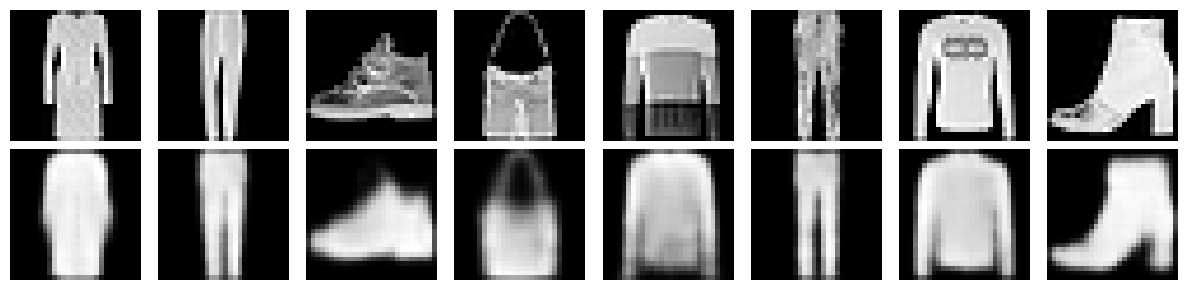

Epoch 02 [  84/421] loss=245.3362 rec=231.3549 kld=13.9814
Epoch 02 [ 168/421] loss=245.2857 rec=230.2739 kld=15.0118
Epoch 02 [ 252/421] loss=260.8769 rec=246.5842 kld=14.2927
Epoch 02 [ 336/421] loss=244.6926 rec=230.4207 kld=14.2718
Epoch 02 [ 420/421] loss=246.0021 rec=230.5237 kld=15.4785
==> Epoch 02 | train: loss=249.4967 rec=234.5772 kld=14.9196 | val: loss=246.3102 rec=231.1131 kld=15.1971
Epoch 03 [  84/421] loss=252.0011 rec=235.7125 kld=16.2886
Epoch 03 [ 168/421] loss=246.5290 rec=230.6566 kld=15.8724
Epoch 03 [ 252/421] loss=251.6822 rec=235.8203 kld=15.8619
Epoch 03 [ 336/421] loss=249.6731 rec=233.4181 kld=16.2550
Epoch 03 [ 420/421] loss=261.6679 rec=245.6198 kld=16.0481
==> Epoch 03 | train: loss=245.4781 rec=229.8938 kld=15.5843 | val: loss=244.0066 rec=228.2116 kld=15.7949
Epoch 04 [  84/421] loss=250.2202 rec=234.7592 kld=15.4610
Epoch 04 [ 168/421] loss=246.7391 rec=230.5419 kld=16.1972
Epoch 04 [ 252/421] loss=249.0262 rec=232.2842 kld=16.7420
Epoch 04 [ 336/421]

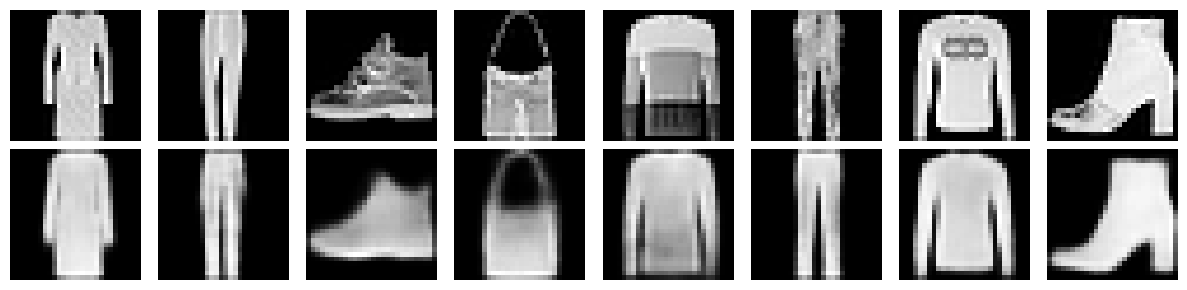

Epoch 06 [  84/421] loss=244.5110 rec=228.3205 kld=16.1905
Epoch 06 [ 168/421] loss=235.2771 rec=219.8284 kld=15.4486
Epoch 06 [ 252/421] loss=246.4877 rec=229.8715 kld=16.6162
Epoch 06 [ 336/421] loss=243.3484 rec=227.4265 kld=15.9219
Epoch 06 [ 420/421] loss=244.8809 rec=228.0286 kld=16.8524
==> Epoch 06 | train: loss=241.3088 rec=225.1815 kld=16.1274 | val: loss=240.5408 rec=224.3480 kld=16.1928
Epoch 07 [  84/421] loss=246.0990 rec=230.5672 kld=15.5318
Epoch 07 [ 168/421] loss=233.1625 rec=217.0179 kld=16.1446
Epoch 07 [ 252/421] loss=251.1781 rec=235.0639 kld=16.1142
Epoch 07 [ 336/421] loss=255.4871 rec=239.0127 kld=16.4744
Epoch 07 [ 420/421] loss=230.8706 rec=214.6833 kld=16.1874
==> Epoch 07 | train: loss=240.5972 rec=224.4355 kld=16.1618 | val: loss=239.9922 rec=224.1433 kld=15.8488
Epoch 08 [  84/421] loss=248.7253 rec=233.2124 kld=15.5129
Epoch 08 [ 168/421] loss=230.9391 rec=213.5541 kld=17.3850
Epoch 08 [ 252/421] loss=237.5964 rec=221.6892 kld=15.9073
Epoch 08 [ 336/421]

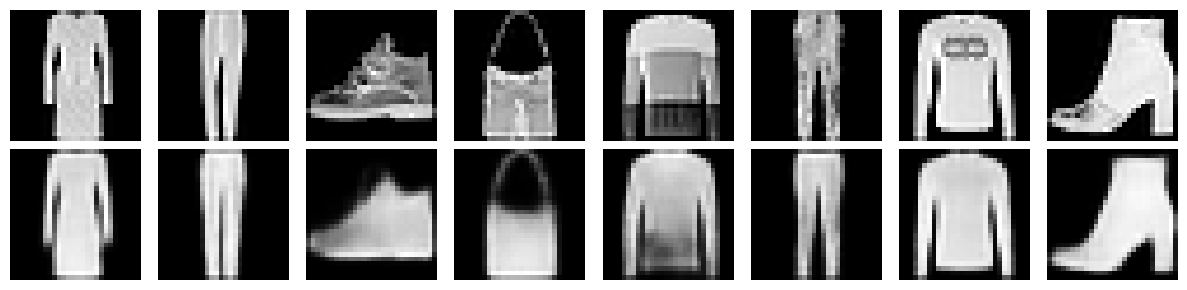

Epoch 11 [  84/421] loss=230.3254 rec=213.9315 kld=16.3939
Epoch 11 [ 168/421] loss=251.1115 rec=235.0333 kld=16.0782
Epoch 11 [ 252/421] loss=234.3796 rec=217.4992 kld=16.8804
Epoch 11 [ 336/421] loss=234.1704 rec=216.9676 kld=17.2028
Epoch 11 [ 420/421] loss=245.7110 rec=229.0192 kld=16.6918
==> Epoch 11 | train: loss=238.7954 rec=222.5756 kld=16.2198 | val: loss=239.0057 rec=221.7257 kld=17.2800
Epoch 12 [  84/421] loss=232.7009 rec=216.3974 kld=16.3035
Epoch 12 [ 168/421] loss=248.2788 rec=232.1744 kld=16.1045
Epoch 12 [ 252/421] loss=235.1671 rec=219.2230 kld=15.9441
Epoch 12 [ 336/421] loss=226.7868 rec=210.7390 kld=16.0478
Epoch 12 [ 420/421] loss=241.2287 rec=225.7335 kld=15.4951
==> Epoch 12 | train: loss=238.5198 rec=222.2770 kld=16.2427 | val: loss=239.0898 rec=222.6006 kld=16.4892
Epoch 13 [  84/421] loss=233.8151 rec=217.6085 kld=16.2066
Epoch 13 [ 168/421] loss=229.8129 rec=213.5452 kld=16.2677
Epoch 13 [ 252/421] loss=245.5648 rec=229.4807 kld=16.0841
Epoch 13 [ 336/421]

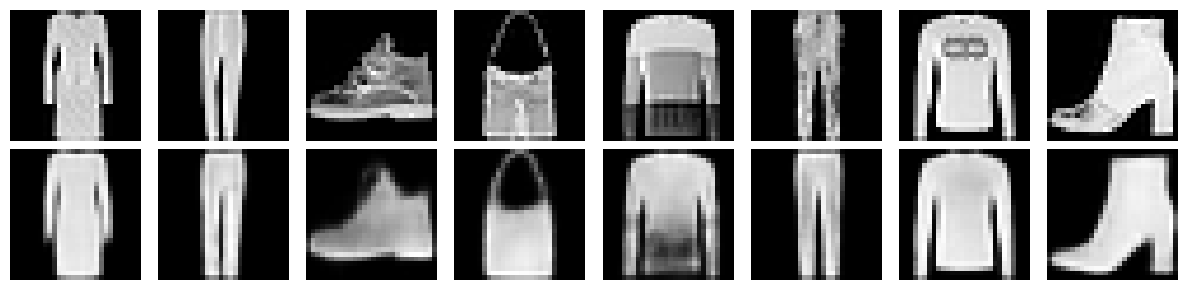

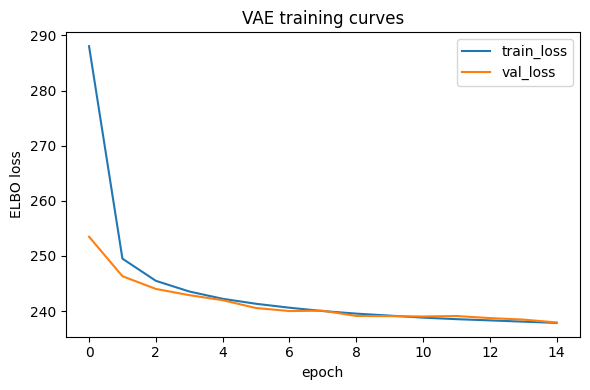

In [7]:
# Dataloaders
BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

# Optimizer & (optional) scheduler
LEARNING_RATE = 1e-3
optimizer = torch.optim.Adam(vae.parameters(), lr=LEARNING_RATE)

# Training config
EPOCHS = 15
BETA = 1.0              # weight on KL term
GRAD_CLIP = 1.0         # set to None to disable
LOG_INTERVAL = max(1, len(train_loader) // 5)

history = {"train_loss": [], "train_rec": [], "train_kld": [],
           "val_loss": [],   "val_rec": [],   "val_kld": []}

for epoch in range(1, EPOCHS + 1):
    # ----- Train -----
    vae.train()
    train_loss = train_rec = train_kld = 0.0
    for step, batch in enumerate(train_loader, start=1):
        x = batch[0].to(device)
        x_hat, mu, logvar, z = vae(x)
        loss, rec, kld = elbo_loss(x_hat, x, mu, logvar, beta=BETA)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(vae.parameters(), GRAD_CLIP)
        optimizer.step()

        train_loss += loss.item()
        train_rec  += rec.item()
        train_kld  += kld.item()

        if step % LOG_INTERVAL == 0:
            print(f"Epoch {epoch:02d} [{step:4d}/{len(train_loader)}] "
                  f"loss={loss.item():.4f} rec={rec.item():.4f} kld={kld.item():.4f}")

    n_train_batches = len(train_loader)
    train_loss /= n_train_batches
    train_rec  /= n_train_batches
    train_kld  /= n_train_batches

    # ----- Validate -----
    vae.eval()
    val_loss = val_rec = val_kld = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x = batch[0].to(device)
            x_hat, mu, logvar, z = vae(x)
            loss, rec, kld = elbo_loss(x_hat, x, mu, logvar, beta=BETA)
            val_loss += loss.item()
            val_rec  += rec.item()
            val_kld  += kld.item()

    n_val_batches = len(val_loader)
    val_loss /= n_val_batches
    val_rec  /= n_val_batches
    val_kld  /= n_val_batches

    history["train_loss"].append(train_loss)
    history["train_rec"].append(train_rec)
    history["train_kld"].append(train_kld)
    history["val_loss"].append(val_loss)
    history["val_rec"].append(val_rec)
    history["val_kld"].append(val_kld)

    print(f"==> Epoch {epoch:02d} | train: loss={train_loss:.4f} rec={train_rec:.4f} kld={train_kld:.4f} "
          f"| val: loss={val_loss:.4f} rec={val_rec:.4f} kld={val_kld:.4f}")

    # Show a quick reconstruction snapshot every few epochs
    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        show_reconstructions(vae, val_ds if val_ds is not None else train_ds, n=8)

# Optional: plot the loss curves
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("ELBO loss"); plt.legend(); plt.title("VAE training curves")
plt.tight_layout(); plt.show()


[Validation] loss=237.9320 rec=222.3462 kld=15.5858


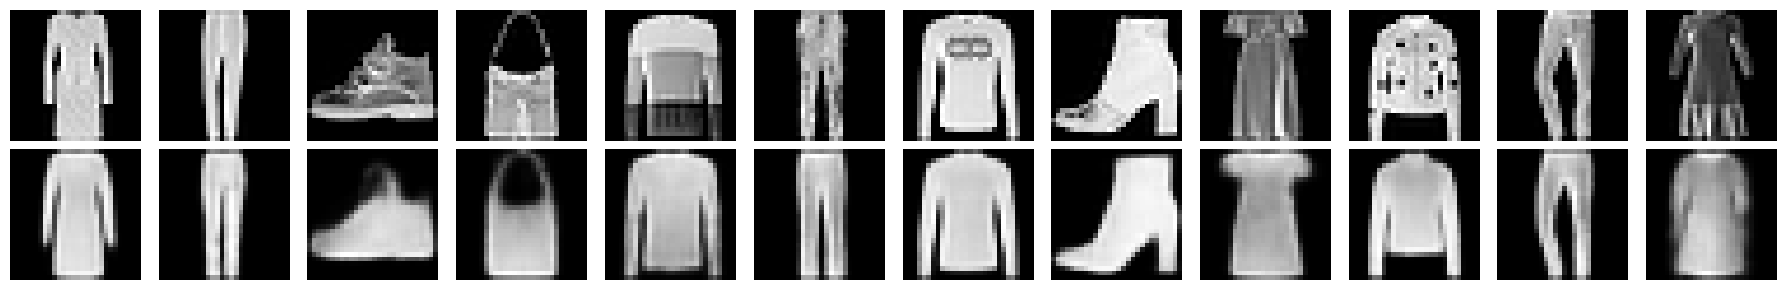

In [8]:
vae.eval()
val_loss = val_rec = val_kld = 0.0
with torch.no_grad():
    for batch in val_loader:
        x = batch[0].to(device)
        x_hat, mu, logvar, z = vae(x)
        loss, rec, kld = elbo_loss(x_hat, x, mu, logvar, beta=BETA)
        val_loss += loss.item()
        val_rec  += rec.item()
        val_kld  += kld.item()

n_val_batches = len(val_loader)
print(f"[Validation] loss={val_loss/n_val_batches:.4f} "
      f"rec={val_rec/n_val_batches:.4f} kld={val_kld/n_val_batches:.4f}")

# Visual qualitative check
show_reconstructions(vae, val_ds if val_ds is not None else train_ds, n=12)


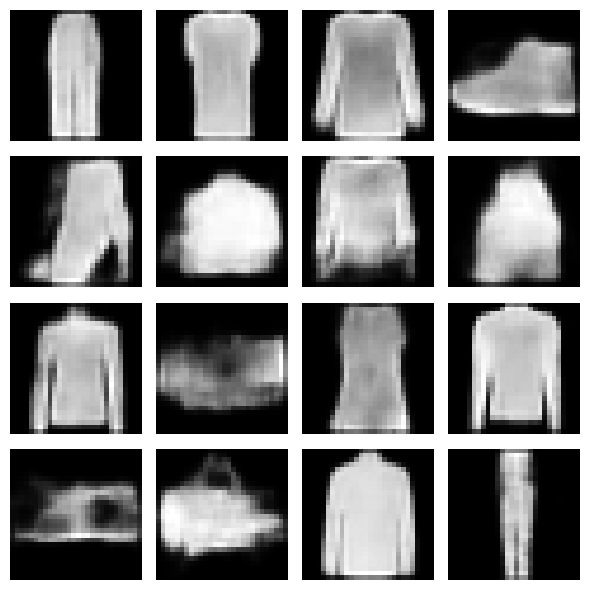

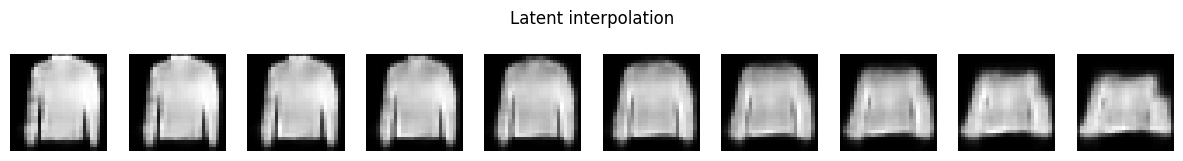

In [9]:
# Draw samples from N(0, I) and decode
show_samples_from_prior(vae, n=16)

# (Optional) Interpolations between two random latent points
with torch.no_grad():
    z1 = torch.randn(1, vae.latent_dim, device=device)
    z2 = torch.randn(1, vae.latent_dim, device=device)
    alphas = torch.linspace(0, 1, steps=10, device=device).view(-1,1)
    z_interp = (1 - alphas) * z1 + alphas * z2
    x_hat = vae.decode(z_interp).detach().cpu().numpy()

fig, axes = plt.subplots(1, 10, figsize=(12, 1.6))
for i in range(10):
    axes[i].imshow(x_hat[i, 0], cmap="gray")
    axes[i].axis("off")
plt.suptitle("Latent interpolation")
plt.tight_layout(); plt.show()


Collected 5000 latent vectors of dim=20


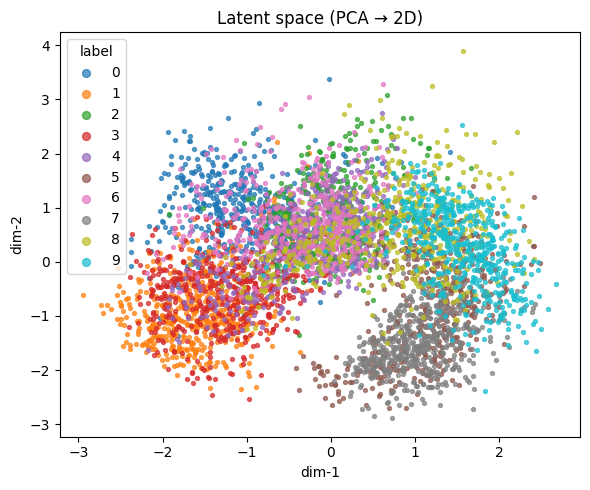

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D projection)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

@torch.no_grad()
def collect_latents(model, data_loader, max_points=5000, use_mu=True):
    """
    Encodes a dataset and returns latent vectors (mu or sampled z) and labels (if present).
    """
    model.eval()
    Z_list, Y_list = [], []
    n = 0
    for batch in data_loader:
        x = batch[0].to(device)
        y = batch[1].cpu().numpy() if len(batch) > 1 else None

        mu, logvar = model.encode(x)
        if use_mu:
            z = mu
        else:
            # sample using reparameterization for visualization (optional)
            eps = torch.randn_like(mu)
            z = mu + torch.exp(0.5 * logvar) * eps

        z = z.cpu().numpy()
        Z_list.append(z)
        if y is not None:
            Y_list.append(y)

        n += z.shape[0]
        if max_points is not None and n >= max_points:
            break

    Z = np.concatenate(Z_list, axis=0)
    if max_points is not None:
        Z = Z[:max_points]
    Y = np.concatenate(Y_list, axis=0)[:len(Z)] if Y_list else None
    return Z, Y

def plot_2d(Z2, Y=None, title="Latent space (2D)"):
    plt.figure(figsize=(6,5))
    if Y is not None:
        # color by label classes if available
        for cls in np.unique(Y):
            idx = (Y == cls)
            plt.scatter(Z2[idx, 0], Z2[idx, 1], s=8, alpha=0.7, label=str(cls))
        plt.legend(title="label", markerscale=2)
    else:
        plt.scatter(Z2[:, 0], Z2[:, 1], s=8, alpha=0.7)
    plt.xlabel("dim-1"); plt.ylabel("dim-2"); plt.title(title)
    plt.tight_layout(); plt.show()

def plot_3d(Z3, Y=None, title="Latent space (3D)"):
    fig = plt.figure(figsize=(6,5))
    ax = fig.add_subplot(111, projection='3d')
    if Y is not None:
        for cls in np.unique(Y):
            idx = (Y == cls)
            ax.scatter(Z3[idx, 0], Z3[idx, 1], Z3[idx, 2], s=8, alpha=0.7, label=str(cls))
        ax.legend(title="label")
    else:
        ax.scatter(Z3[:, 0], Z3[:, 1], Z3[:, 2], s=8, alpha=0.7)
    ax.set_xlabel("dim-1"); ax.set_ylabel("dim-2"); ax.set_zlabel("dim-3")
    ax.set_title(title)
    plt.tight_layout(); plt.show()

# ---- Collect latents from validation (or train if val not available)
vis_loader = DataLoader(val_ds if val_ds is not None else train_ds, batch_size=256, shuffle=False)
Z, Y = collect_latents(vae, vis_loader, max_points=5000, use_mu=True)

latent_dim = Z.shape[1]
print(f"Collected {Z.shape[0]} latent vectors of dim={latent_dim}")

# ---- Choose visualization strategy
# If latent_dim == 2 or 3, plot directly; otherwise reduce with PCA (fast) or t-SNE (slower, prettier)
REDUCE_METHOD = "pca"   # options: "pca" or "tsne"
TARGET_DIM = 2          # set to 3 for 3D PCA/t-SNE

if latent_dim == 2:
    plot_2d(Z, Y, title="Latent space (native 2D)")
elif latent_dim == 3:
    plot_3d(Z, Y, title="Latent space (native 3D)")
else:
    if REDUCE_METHOD.lower() == "pca":
        reducer = PCA(n_components=TARGET_DIM, random_state=SEED)
        Z_red = reducer.fit_transform(Z)
        if TARGET_DIM == 2:
            plot_2d(Z_red, Y, title="Latent space (PCA → 2D)")
        else:
            plot_3d(Z_red, Y, title="Latent space (PCA → 3D)")
    else:
        # t-SNE is slower; you can lower n_iter/perplexity for speed on big sets
        reducer = TSNE(n_components=TARGET_DIM, learning_rate="auto",
                       init="pca", perplexity=30, random_state=SEED, n_iter=1000)
        Z_red = reducer.fit_transform(Z)
        if TARGET_DIM == 2:
            plot_2d(Z_red, Y, title="Latent space (t-SNE → 2D)")
        else:
            plot_3d(Z_red, Y, title="Latent space (t-SNE → 3D)")
